In [10]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os

In [11]:
manhattan_shapes = pd.read_csv('./output/manhattan_shapes.csv')
manhattan_shapes['ZIP Code'] = manhattan_shapes['ZIP Code'].astype(str)

In [12]:
income_2023 = pd.read_csv(os.path.join('income', 'income_2023.csv'))
split_name = income_2023['NAME'].str.split(' ')

income_2023['ZIP Code'] = split_name.str[-1]

In [13]:
gdf_with_income = manhattan_shapes.merge(income_2023, left_on='ZIP Code', right_on='ZIP Code', how='left')

In [14]:
from shapely import wkt
import geopandas as gpd

# Convert the 'geometry' column from WKT text to real shapely objects
gdf_with_income['geometry'] = gdf_with_income['geometry'].apply(wkt.loads)

# Now make it a GeoDataFrame
gdf_with_income = gpd.GeoDataFrame(gdf_with_income, geometry='geometry')

# (Optional but good practice) Set the CRS
gdf_with_income = gdf_with_income.set_crs(epsg=4326)  # WGS84 latitude/longitude

In [15]:
constant = ['ZIP Code', 'geometry',]
sections = ['S1901_C02_012E', 'S1901_C02_013E']
section_labels = [
    'Median Household Income',
    "Mean Household Income",
]
# only keep columns in sections
gdf_with_income = gdf_with_income[gdf_with_income.columns[gdf_with_income.columns.isin(sections + constant)]]

In [16]:
def clean_income(val):
    if isinstance(val, str):
        val = val.replace(",", "").replace("+", "")
    return float(val)

gdf_with_income['S1901_C02_012E'] = gdf_with_income['S1901_C02_012E'].apply(clean_income)
gdf_with_income['S1901_C02_013E'] = gdf_with_income['S1901_C02_013E'].apply(clean_income)

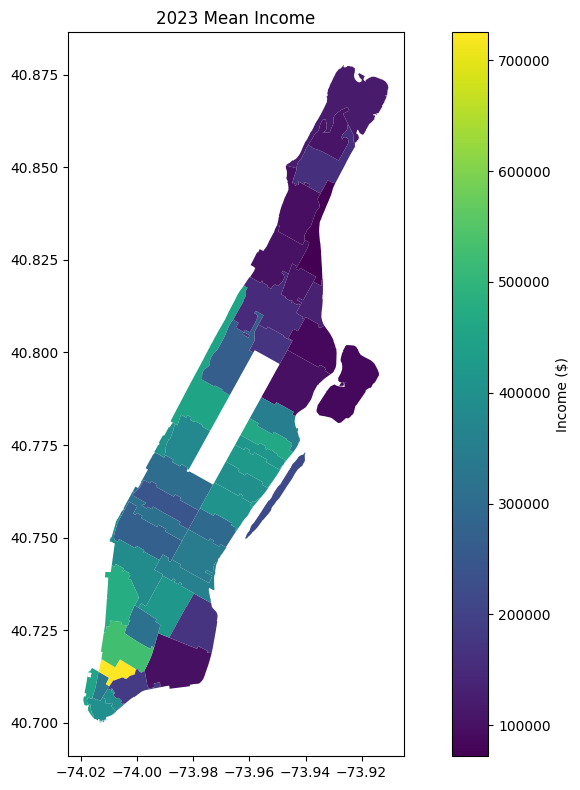

In [17]:
cmap = plt.cm.viridis

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the GeoDataFrame
gdf_with_income.plot(
    column='S1901_C02_013E',
    cmap=cmap,
    ax=ax,
    legend=True,
    legend_kwds={'label': "Income ($)", 'orientation': "vertical"}
)

plt.title("2023 Mean Income")
plt.tight_layout()
plt.show()

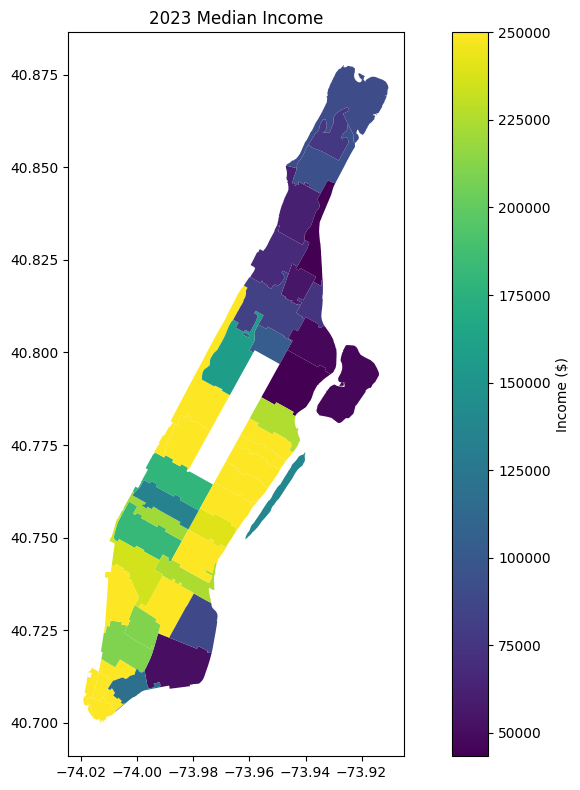

In [18]:
cmap = plt.cm.viridis

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the GeoDataFrame
gdf_with_income.plot(
    column='S1901_C02_012E',
    cmap=cmap,
    ax=ax,
    legend=True,
    legend_kwds={'label': "Income ($)", 'orientation': "vertical"}
)

plt.title("2023 Median Income")
plt.tight_layout()
plt.show()

In [19]:
gdf_with_income.to_csv('./output/income.csv', index=False)